# <span style = "color:coral"> Customer Behaviour Classification </span>

***

In this project, we will try to predict if the customer purchase the product or not using various machine learning models and Deploy the model with Tkinter library

## Contents

The data represents details about 400 clients of a company including the unique ID, the gender, the age of the customer and the salary. Besides this, we have collected information regarding the buying decision - weather the customer decided to buy specific products or not.

## Let's Begin

### Import all necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read 'Customer_Behaviour.csv' dataset and store it in a dataframe variable

In [2]:
df = pd.read_csv('Customer_Behaviour.csv')


### View the top 5 rows

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### View info of the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 14.1+ KB


### View basic statistical information about the dataset

In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


### Check for any null values

In [6]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

### View unique values in Gender

In [7]:
print(df['Gender'].unique)

<bound method Series.unique of 0        Male
1        Male
2      Female
3      Female
4        Male
        ...  
395    Female
396      Male
397    Female
398      Male
399    Female
Name: Gender, Length: 400, dtype: object>


#### Drop user ID column

In [8]:
df.drop('User ID', axis=1, inplace=True)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


## <span style = "color: orange"> Data Visualization </span>

### Plot heatmap to view the correlation between features

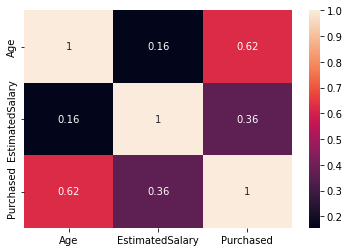

In [9]:

corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()


### Plot a countplot of gender with respect to purchased

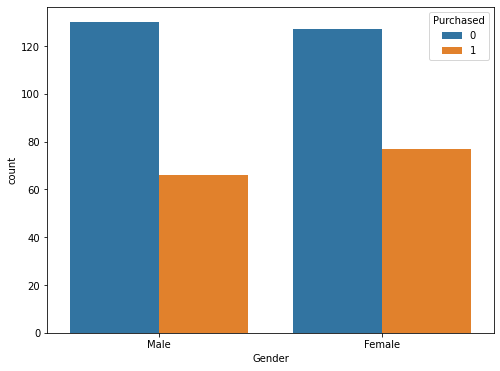

In [10]:
plt.figure(figsize=(8,6))
sns.countplot(x='Gender', hue='Purchased', data=df)

plt.show()



### Plot a displot of Age

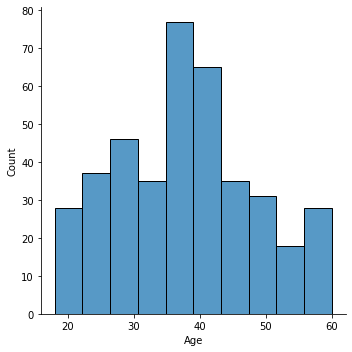

In [11]:
sns.displot(x='Age',data = df)
plt.show()

### Plot pairplot of the dataset

<Figure size 720x720 with 0 Axes>

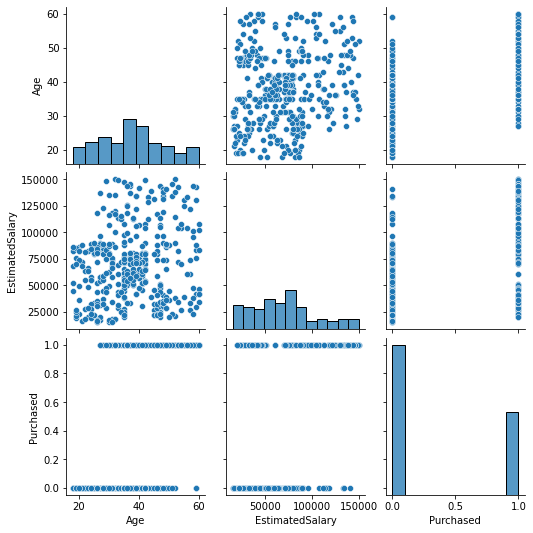

In [12]:
plt.figure(figsize=(10,10))

sns.pairplot(df)
plt.show()

## Data Preprocessing

In [13]:
dummy = pd.get_dummies(df['Gender'])
data = pd.concat([df,dummy], axis = 1)
data.head()

,Gender,Age,EstimatedSalary,Purchased,Female,Male
0,Male,19,19000,0,0,1
1,Male,35,20000,0,0,1
2,Female,26,43000,0,1,0
3,Female,27,57000,0,1,0
4,Male,19,76000,0,0,1


### Split the dataset into input and target variables

In [14]:
df.columns

Index(['Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [15]:
X = df.drop(columns=['Purchased'])
y = df['Purchased']

### Scale the data using StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler =  StandardScaler()

In [18]:
X = pd.get_dummies(X)

In [19]:
X = pd.DataFrame(scaler.fit_transform(X),columns = X.columns)


In [20]:
X.head()

,Age,EstimatedSalary,Gender_Female,Gender_Male
0,-1.781797,-1.490046,-1.020204,1.020204
1,-0.253587,-1.460681,-1.020204,1.020204
2,-1.113206,-0.785290,0.980196,-0.980196
3,-1.017692,-0.374182,0.980196,-0.980196
4,-1.781797,0.183751,-1.020204,1.020204


### Split the dataset into training and testing set

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size = 0.25)

### Check shape of X_train and X_test

In [23]:
X_train.shape

(300, 4)

In [24]:
X_test.shape

(100, 4)

## ML Models

### Logistic Regression Classifier

In [25]:
from sklearn.linear_model import LogisticRegression
from  sklearn import metrics
from sklearn.model_selection import cross_val_score

In [26]:
logisctic_reg = LogisticRegression()

In [27]:
logisctic_reg.fit(X_train, y_train)

LogisticRegression()

In [28]:
print('score of our trained model is :',logisctic_reg.score(X_train, y_train))

score of our trained model is : 0.8666666666666667


In [29]:
logistic_pred = logisctic_reg.predict(X_test)

In [30]:
from sklearn import metrics

In [31]:
print('Accuracy score of our prediction is:',metrics.accuracy_score(y_test,logistic_pred))

Accuracy score of our prediction is: 0.78


In [32]:
print('Confision matrix is:\n',metrics.confusion_matrix(y_test, logistic_pred))
print('Classification report is:\n',metrics.classification_report(y_test, logistic_pred))

Confision matrix is:
 [[52  8]
 [14 26]]
Classification report is:
               precision    recall  f1-score   support

           0       0.79      0.87      0.83        60
           1       0.76      0.65      0.70        40

    accuracy                           0.78       100
   macro avg       0.78      0.76      0.76       100
weighted avg       0.78      0.78      0.78       100



In [33]:

scores = cross_val_score(logisctic_reg, X, y, cv=5)

mean_score = np.mean(scores)

print("Mean of cross validation score is: ", mean_score)


Mean of cross validation score is:  0.82


### Random Forest Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
random_fore = RandomForestClassifier(n_estimators=20)
                                        
random_fore.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [37]:
random_pred = random_fore.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, random_pred)
print('Accuracy score of our prediction is:',accuracy)

Accuracy score of our prediction is: 0.87


In [39]:
cm = confusion_matrix(y_test, random_pred)
print('Confusion metrix is:\n',cm)

Confusion metrix is:
 [[50 10]
 [ 3 37]]


In [40]:
cr = classification_report(y_test,random_pred)
print('Classification report is:\n',cr )

Classification report is:
               precision    recall  f1-score   support

           0       0.94      0.83      0.88        60
           1       0.79      0.93      0.85        40

    accuracy                           0.87       100
   macro avg       0.87      0.88      0.87       100
weighted avg       0.88      0.87      0.87       100



In [41]:
cv_score = cross_val_score(random_fore, X, y, cv=5)
print('Mean of Cross validation is:',cv_score.mean())

Mean of Cross validation is: 0.8525


### Support Vector Machine

In [42]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [43]:
support_vect = GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.75, 0.85, 0.95, 1], 'degree': [3, 4, 5],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})
support_vect.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.75, 0.85, 0.95, 1], 'degree': [3, 4, 5],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [44]:
best_estimator = support_vect.best_estimator_
best_params = support_vect.best_params_
best_score = support_vect.best_score_

print("Best estimator is: ", best_estimator)
print("Best parameters are: ", best_params)
print("Best score is: ", best_score)

Best estimator is:  SVC(C=0.75)
Best parameters are:  {'C': 0.75, 'degree': 3, 'kernel': 'rbf'}
Best score is:  0.9066666666666666


In [45]:
support_pred = support_vect.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, support_pred)
print('Accuracy score of our prediction is:',accuracy)

Accuracy score of our prediction is: 0.9


In [47]:
cm = confusion_matrix(y_test, support_pred)
print('Confusion metrix is:\n',cm)

Confusion metrix is:
 [[52  8]
 [ 2 38]]


In [48]:
cr = classification_report(y_test,support_pred)
print('Classification report is:\n',cr )

Classification report is:
               precision    recall  f1-score   support

           0       0.96      0.87      0.91        60
           1       0.83      0.95      0.88        40

    accuracy                           0.90       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.90      0.90       100



In [49]:
cv_score = cross_val_score(support_vect, X, y, cv=5)
print('Mean of Cross validation score is:',cv_score.mean())

Mean of Cross validation score is: 0.9


### Assign cross val scores of all models into a dataframe

In [51]:


random_score = accuracy_score(y_test,random_pred)
support_score = accuracy_score(y_test, support_pred)
logistic_score = accuracy_score(y_test, logistic_pred)


In [52]:
import pandas as pd

scores = {'Models':['Random Forest Classifier','Support Vector Classifier','Logistic Regression'],
           'Scores':[ random_score,support_score,logistic_score]}
  

df = pd.DataFrame(scores)

df

,Models,Scores
0,Random Forest Classifier,0.87
1,Support Vector Classifier,0.90
2,Logistic Regression,0.78


***

## Deploy the model with highest score using Tkinter

In [146]:
### In this case its SVM Classifier

In [53]:
import tkinter as tk

def deploy_model(highest_score):

    print(f"Deploying model with highest score: {highest_score}")

root = tk.Tk()
root.title("Model Deployment")

highest_score = 0.91 

deploy_button = tk.Button(root, text="Deploy Model", command=lambda: deploy_model(highest_score))
deploy_button.pack()

root.mainloop()


Deploying model with highest score: 0.91


In [119]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = model.score(X_test, y_test)

#### Import all modules from Tkinter

In [120]:
from tkinter import *
from tkinter.ttk import Combobox

### Define a function that will output to an entry box in Tkinter¶

In [121]:
def getPrediction():
    # .get() function is used to fetch the value from the entrybox and radiobuttons
    age1 = int(age.get())
    salary1 = int(salary.get())
    
    resultbox.delete(0, END)
    
    if gender.get() == 1:
        male = 1
        female = 0
    else:
        male = 0
        female = 1
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    result = model.predict(scaler.transform([[age1, salary1,male,female]]))
    
    if result[0] == 1:
        resultbox.insert(0, 'Purchased')
    elif result[0] == 0:
        resultbox.insert(0, 'Not Purchased')
    else:
        resultbox.insert(0, 'Error')
        

### Create tkinter window with all necessary entryboxes and labels

In [123]:
window = Tk()
window.geometry("350x400")

titlelabel = Label(window, text = 'Costumer Behaviuor Prediction', bg ='blue').pack(fill = 'both')

agelabel = Label(window, text = 'Age')
age = Entry(window)

salarylabel = Label(window, text = 'Estimated Salary')
salary = Entry(window)
Label(window).pack()

gender = StringVar()
gender.set(1)
genderlabel = Label(window, text = 'Gender')

agelabel.pack()
age.pack()
Label(window).pack()

salarylabel.pack()
salary.pack()
Label(window).pack()

genderlabel.pack()
Radiobutton(window, text = 'male', variable = gender , value = 1).pack()
Radiobutton(window, text = 'female', variable = gender , value = 2).pack()
Label(window).pack()


button = Button(window, text = 'Get Prediction', command = getPrediction).pack()
Label(window).pack()

resultbox = Entry(window)
resultbox.pack()

window.mainloop()

***